In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

In [2]:
from functions import dL_rosenbrock_1d
import pandas as pd
from src.optimizer import AdamScratch1D
from src.utils import AdamPlotter
import matplotlib.pyplot as plt
import numpy as np
from config import *

# DISCRETE-ADAM

In [3]:

optimizer = AdamScratch1D(
    dL = dL_rosenbrock_1d,
    lr=lr,
    beta1=beta1,
    beta2=beta2,
    epsilon=epsilon,
    epochs=epochs
)

theta_history, m_history, v_history, iterations = optimizer.solve(
    theta_initial=initial_theta,
    function_parameters=(c_value,)
    )

print(f"Final value of theta: {theta_history[-1]}")


Epoch: 50, theta=8.724706e-01, Error: 4.101605e-02
Epoch: 100, theta=1.992009e+00, Error: 2.503058e-03
Epoch: 150, theta=1.463540e+00, Error: 1.804941e-02
Epoch: 200, theta=6.399205e-01, Error: 1.122273e-02
Epoch: 250, theta=5.311263e-01, Error: 5.829329e-03
Epoch: 300, theta=1.006571e+00, Error: 1.014962e-02
Epoch: 350, theta=1.298880e+00, Error: 5.493947e-04
Epoch: 400, theta=1.100583e+00, Error: 6.583720e-03
Epoch: 450, theta=8.406005e-01, Error: 2.363614e-03
Epoch: 500, theta=9.025668e-01, Error: 3.844802e-03
Epoch: 550, theta=1.085380e+00, Error: 2.174910e-03
Epoch: 600, theta=1.067400e+00, Error: 2.344623e-03
Epoch: 650, theta=9.476693e-01, Error: 1.466223e-03
Epoch: 700, theta=9.611379e-01, Error: 1.602833e-03
Epoch: 750, theta=1.036995e+00, Error: 7.635207e-04
Epoch: 800, theta=1.017176e+00, Error: 1.174043e-03
Epoch: 850, theta=9.730531e-01, Error: 2.033271e-04
Epoch: 900, theta=9.976826e-01, Error: 8.144890e-04
Epoch: 950, theta=1.017335e+00, Error: 1.689247e-04
Epoch: 1000, 

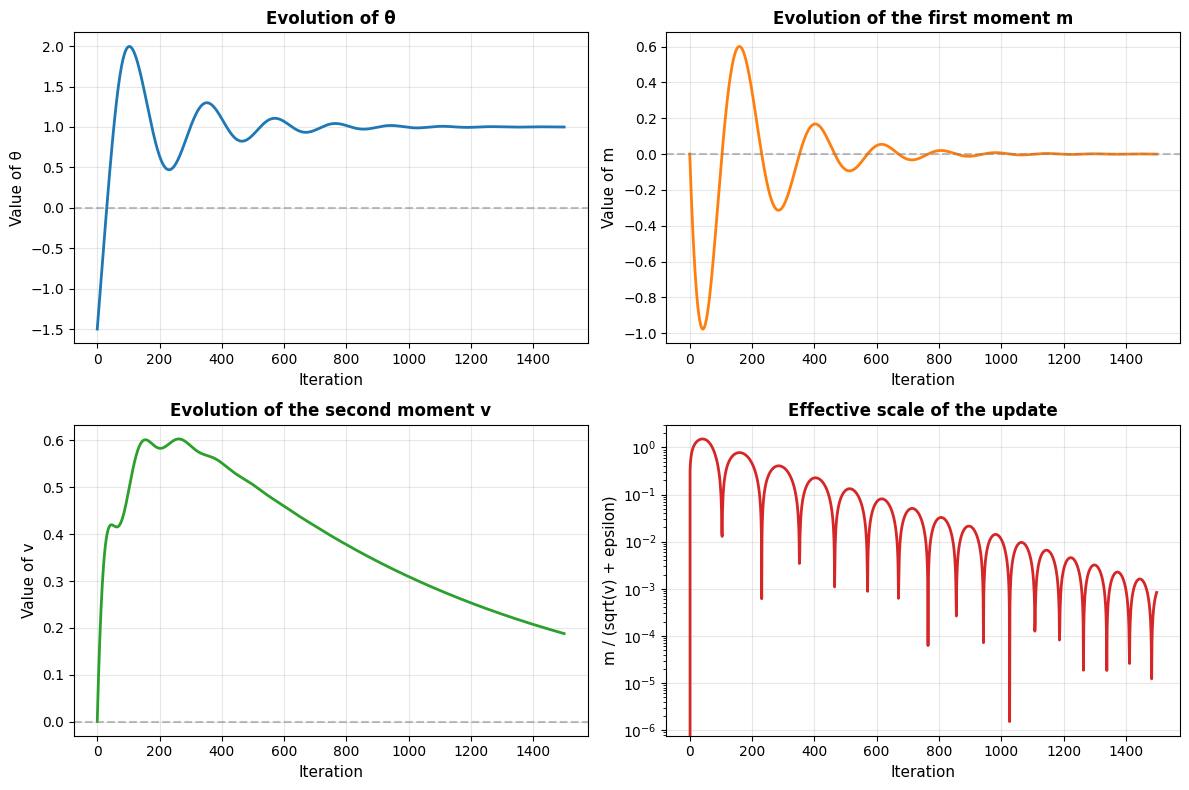

In [4]:
# Create Plotter and visualize
plotter = AdamPlotter(theta_history, m_history, v_history)

# Plot all
plotter.plot('all')
plt.show()

## Save Results

In [5]:
# Create DataFrame
df_discrete = pd.DataFrame({
    't': np.arange(len(theta_history)),
    'theta_history': theta_history,
    'theta_dot_history': None,
    'theta_ddot_history': None,
    'm_history': m_history,
    'v_history': v_history
})

# Save to CSV
df_discrete.to_csv(f'results/c_{c_value}_results_initial_theta_{initial_theta}_lr_{lr}_beta1_{beta1}_beta2_{beta2}.csv', index=False)
print(f"Results saved in 'results/c_{c_value}_results_initial_theta_{initial_theta}_lr_{lr}_beta1_{beta1}_beta2_{beta2}.csv'")
print(f"Total rows: {len(df_discrete)}")

Results saved in 'results/c_0.0_results_initial_theta_-1.5_lr_0.05_beta1_0.99_beta2_0.999.csv'
Total rows: 1500
